# CondFD Sky Longwave Radiation Override

Override the sky longwave radiation term (`hsky * (Tsky - Tsurf)`) on CondFD exterior surfaces
with a user-supplied net sky radiation flux (W/mÂ²). Works with **any IDF/EPW pair**.

### Sign convention

| Enet value | Meaning |
|---|---|
| **Negative** (e.g. -200) | Surface loses heat to sky (typical nighttime cooling) |
| **Zero** | No sky LW exchange |
| **Positive** (e.g. +200) | Sky heats the surface (unusual but valid) |

### Requirements

- EnergyPlus build with Python API support
- IDF must use `HeatBalanceAlgorithm: ConductionFiniteDifference` (globally or per-surface)
- `pandas` and `matplotlib` for results display

---
## Step 1: Configuration

Edit the three paths below. Everything else is auto-detected.

In [1]:
# ============================================================
# EDIT THESE THREE PATHS
# ============================================================

ENERGYPLUS_DIR = r"C:\projects\EnergyPlus\build\Products\Release"
IDF_FILE       = r"C:\projects\EnergyPlus\testfiles\1ZoneCondFD_Enet_Test.idf"
EPW_FILE       = r"C:\projects\EnergyPlus\weather\USA_CO_Golden-NREL.724666_TMY3.epw"

---
## Step 2: Parse IDF and find eligible surfaces

In [2]:
import re
from pathlib import Path

def parse_idf_objects(idf_text):
    """Parse IDF text into a list of (object_type, [field_values]) tuples."""
    lines = []
    for line in idf_text.splitlines():
        idx = line.find("!")
        if idx >= 0:
            line = line[:idx]
        lines.append(line.strip())
    text = " ".join(lines)
    objects = []
    for obj_str in text.split(";"):
        obj_str = obj_str.strip()
        if not obj_str:
            continue
        fields = [f.strip() for f in obj_str.split(",")]
        if fields:
            objects.append((fields[0], fields[1:]))
    return objects


def find_condfd_exterior_surfaces(idf_path):
    """Find all exterior surfaces that use CondFD heat balance."""
    idf_text = Path(idf_path).read_text(encoding="utf-8", errors="replace")
    objects = parse_idf_objects(idf_text)

    global_condfd = False
    for obj_type, fields in objects:
        if obj_type.lower() == "heatbalancealgorithm" and fields:
            if "conductionfinitedifference" in fields[0].lower():
                global_condfd = True
            break

    per_surface_algo = {}
    condfd_constructions = set()
    for obj_type, fields in objects:
        ot = obj_type.lower()
        if ot == "surfaceproperty:heattransferalgorithm" and len(fields) >= 2:
            per_surface_algo[fields[0].upper()] = fields[1].lower()
        elif ot == "surfaceproperty:heattransferalgorithm:surfacelist" and len(fields) >= 3:
            algo = fields[1].lower()
            for surf_name in fields[2:]:
                if surf_name:
                    per_surface_algo[surf_name.upper()] = algo
        elif ot == "surfaceproperty:heattransferalgorithm:construction" and len(fields) >= 3:
            if "conductionfinitedifference" in fields[1].lower():
                condfd_constructions.add(fields[2].upper())

    surface_types = {
        "buildingsurface:detailed", "wall:detailed", "roofceiling:detailed",
        "floor:detailed", "wall:exterior", "roof",
    }

    surfaces = []
    for obj_type, fields in objects:
        ot = obj_type.lower()
        if ot not in surface_types:
            continue
        if ot == "buildingsurface:detailed" and len(fields) >= 6:
            name, stype, construction, zone = fields[0], fields[1], fields[2], fields[3]
            bc = fields[5]
        elif ot in ("wall:detailed", "roofceiling:detailed", "floor:detailed") and len(fields) >= 5:
            name, stype, construction, zone = fields[0], ot.split(":")[0].capitalize(), fields[1], fields[2]
            bc = fields[4]
        elif ot == "wall:exterior" and len(fields) >= 3:
            name, stype, construction, zone, bc = fields[0], "Wall", fields[1], fields[2], "Outdoors"
        elif ot == "roof" and len(fields) >= 3:
            name, stype, construction, zone, bc = fields[0], "Roof", fields[1], fields[2], "Outdoors"
        else:
            continue
        if bc.lower() != "outdoors":
            continue
        name_upper = name.upper()
        if name_upper in per_surface_algo:
            is_condfd = "conductionfinitedifference" in per_surface_algo[name_upper]
        elif construction.upper() in condfd_constructions:
            is_condfd = True
        else:
            is_condfd = global_condfd
        if is_condfd:
            surfaces.append({"name": name, "type": stype, "construction": construction, "zone": zone})

    return surfaces


eligible = find_condfd_exterior_surfaces(IDF_FILE)
if not eligible:
    print("ERROR: No exterior CondFD surfaces found.")
else:
    print(f"Found {len(eligible)} eligible surface(s):\n")
    for i, s in enumerate(eligible):
        print(f"  [{i}] {s['name']:30s}  {s['type']:6s}  construction={s['construction']}  zone={s['zone']}")

Found 5 eligible surface(s):

  [0] Zn001:Wall001                   Wall    construction=R13WALL  zone=ZONE ONE
  [1] Zn001:Wall002                   Wall    construction=R13WALL  zone=ZONE ONE
  [2] Zn001:Wall003                   Wall    construction=R13WALL  zone=ZONE ONE
  [3] Zn001:Wall004                   Wall    construction=R13WALL  zone=ZONE ONE
  [4] Zn001:Roof001                   Roof    construction=ROOF_CONCRETE  zone=ZONE ONE


---
## Step 3: Choose surfaces, Enet values, and run period

In [3]:
# Which surfaces to override?
#   "all"              - all eligible surfaces
#   [0, 2]             - by index from the list above
#   ["Zn001:Roof001"]  - by name
SURFACES = "all"

# Enet values to test (W/m2). Baseline (no override) is always included.
ENET_VALUES = [0, -200]

# Run period:
#   "design_day" â€” uses IDF design days only (fast, but winter+summer overlap on x-axis)
#   "annual"     â€” full year
#   (start_month, start_day, end_month, end_day) â€” custom date range
RUN_PERIOD = (7, 1, 7, 7)  # July 1-7

# ============================================================
# Resolve surface selection
# ============================================================
if SURFACES == "all":
    target_surfaces = [s["name"] for s in eligible]
elif isinstance(SURFACES, list) and len(SURFACES) > 0:
    if isinstance(SURFACES[0], int):
        target_surfaces = [eligible[i]["name"] for i in SURFACES]
    else:
        target_surfaces = list(SURFACES)
else:
    target_surfaces = [s["name"] for s in eligible]

run_configs = [None] + [e for e in ENET_VALUES if e is not None]

print(f"Surfaces: {target_surfaces}")
print(f"Runs: baseline + Enet = {[e for e in ENET_VALUES]}")
print(f"Run period: {RUN_PERIOD}")
print(f"Total simulations: {len(run_configs)}")

Surfaces: ['Zn001:Wall001', 'Zn001:Wall002', 'Zn001:Wall003', 'Zn001:Wall004', 'Zn001:Roof001']
Runs: baseline + Enet = [0, -200]
Run period: (7, 1, 7, 7)
Total simulations: 3


---
## Step 4: Run simulations

In [4]:
import sys
import json
import subprocess
from pathlib import Path
from tempfile import mkdtemp
from datetime import datetime

ep_path = str(Path(ENERGYPLUS_DIR).resolve())
if ep_path not in sys.path:
    sys.path.insert(0, ep_path)

from pyenergyplus.api import EnergyPlusAPI


def make_run_epjson(idf_path, ep_dir, start_month, start_day, end_month, end_day):
    """Convert an IDF to epJSON and patch it for a custom weather-period run.

    Uses `energyplus --convert-only` to do a lossless IDFâ†’epJSON conversion,
    then:
      1. Replaces RunPeriod with a single custom date window.
      2. Patches SimulationControl to enable weather-period runs and disable
         sizing-period runs (guards against IDFs that have the flags inverted).

    Returns the path to the patched .epJSON temp file.
    """
    ep_exe = str(Path(ep_dir) / "energyplus.exe")
    tmp_dir = mkdtemp(prefix="enet_epjson_")

    # --convert-only: parse IDF, write epJSON, exit without simulating.
    # -d: put output in our temp dir so we don't clutter the IDF source folder.
    result = subprocess.run(
        [ep_exe, "--convert-only", "-d", tmp_dir, str(idf_path)],
        capture_output=True, text=True
    )

    epjson_path = Path(tmp_dir) / (Path(idf_path).stem + ".epJSON")
    if not epjson_path.exists():
        raise FileNotFoundError(
            f"epjson conversion failed.\nstdout: {result.stdout}\nstderr: {result.stderr}"
        )

    with open(epjson_path) as f:
        epjson = json.load(f)

    # 1. Replace all RunPeriod entries with a single custom window.
    #    epJSON stores objects as dicts keyed by instance name.
    epjson["RunPeriod"] = {
        "Enet_Override_Period": {
            "begin_month":                                 start_month,
            "begin_day_of_month":                          start_day,
            "end_month":                                   end_month,
            "end_day_of_month":                            end_day,
            "day_of_week_for_start_day":                   "Tuesday",
            "use_weather_file_holidays_and_special_days":  "Yes",
            "use_weather_file_daylight_saving_period":     "Yes",
            "apply_weekend_holiday_rule":                  "No",
            "use_weather_file_rain_indicators":            "Yes",
            "use_weather_file_snow_indicators":            "Yes",
        }
    }

    # 2. Patch SimulationControl so we always run weather periods and skip
    #    sizing periods.  Some IDFs (like the 1-zone test IDF) ship with
    #    run_simulation_for_weather_file_run_periods = No; without this patch
    #    EnergyPlus would run design days only and ignore our custom RunPeriod.
    if "SimulationControl" in epjson:
        for sc_obj in epjson["SimulationControl"].values():
            sc_obj["run_simulation_for_weather_file_run_periods"] = "Yes"
            sc_obj["run_simulation_for_sizing_periods"] = "No"

    out_path = Path(tmp_dir) / (Path(idf_path).stem + "_enet_run.epJSON")
    with open(out_path, "w") as f:
        json.dump(epjson, f, indent=2)

    return str(out_path)


def run_single(idf_file, epw_file, target_surfaces, enet_value, run_period):
    """Run one EnergyPlus simulation with an optional constant sky LW override.

    Args:
        idf_file:        Path to IDF or epJSON input file.
        epw_file:        Path to EPW weather file.
        target_surfaces: List of surface names to override.
        enet_value:      Constant Enet flux (W/mÂ²) to apply, or None for baseline
                         (actuator never set â†’ EnergyPlus uses its standard sky term).
        run_period:      "design_day" to add -D flag; any other value runs weather periods.

    The callback fires at callback_begin_zone_timestep_after_init_heat_balance,
    which is before ExteriorBCEqns runs.  This is the correct point to set
    actuator values so they take effect in the current timestep's heat balance.

    Output variable values read via get_variable_value reflect the PREVIOUS timestep
    (values are written at the end of each timestep solve).  Therefore we skip the
    first real timestep after warmup ends: its variable values come from the last
    warmup step and may be extreme/uninitialized.

    Returns (list_of_data_dicts, run_dir_path).
    """
    _api = EnergyPlusAPI()
    _state = _api.state_manager.new_state()
    label = f"Enet={enet_value}" if enet_value is not None else "baseline"
    _run_dir = mkdtemp(prefix=f"enet_{label}_")
    _data = []

    def _make_callback():
        # Mutable containers used as closures (Python 2-style workaround for nonlocal).
        ready = [False]          # True once all handles have been looked up
        act_handles = [{}]       # surf_name â†’ actuator handle int
        var_handles = [{}]       # surf_name â†’ dict of output-variable handle ints
        global_vh = [{}]         # site-level variable handles (OAT, sky temp)
        post_warmup = [True]     # True until the first real non-warmup timestep has been skipped

        def _cb(st):
            # --- One-time handle lookup ---
            # api_data_fully_ready returns False during early init before all
            # output variables, actuators, and meters have been registered.
            if not ready[0]:
                if not _api.exchange.api_data_fully_ready(st):
                    return

                for surf in target_surfaces:
                    # get_actuator_handle: looks up the EMS actuator by
                    # (component_type, control_type, actuator_key).
                    # Returns -1 if the actuator doesn't exist for this surface.
                    h = _api.exchange.get_actuator_handle(
                        st, "CondFD Surface", "Sky Longwave Radiation Override", surf)
                    if h == -1:
                        print(f"  WARNING: actuator not found for '{surf}'")
                        continue
                    act_handles[0][surf] = h

                    # get_variable_handle: looks up an EnergyPlus output variable
                    # by (variable_name, key_value).  Returns -1 if not found.
                    var_handles[0][surf] = {
                        "surf_temp": _api.exchange.get_variable_handle(
                            st, "Surface Outside Face Temperature", surf),
                        "lw_rad": _api.exchange.get_variable_handle(
                            st, "Surface Outside Face Net Thermal Radiation Heat Gain Rate per Area", surf),
                        "conv": _api.exchange.get_variable_handle(
                            st, "Surface Outside Face Convection Heat Gain Rate per Area", surf),
                        "cond": _api.exchange.get_variable_handle(
                            st, "Surface Outside Face Conduction Heat Transfer Rate per Area", surf),
                    }

                # Site-level variables use "Environment" as the key.
                global_vh[0] = {
                    "oat":      _api.exchange.get_variable_handle(
                        st, "Site Outdoor Air Drybulb Temperature", "Environment"),
                    "sky_temp": _api.exchange.get_variable_handle(
                        st, "Site Sky Temperature", "Environment"),
                }
                ready[0] = True

            # --- Apply constant actuator value every timestep ---
            # When enet_value is None (baseline), we never touch the actuator so
            # EnergyPlus runs its standard hsky*(Tsky-Tsurf) sky radiation term.
            if enet_value is not None:
                for surf, h in act_handles[0].items():
                    # set_actuator_value overrides the sky LW term for this timestep.
                    # The value (W/mÂ²) replaces hsky*(Tsky-Tsurf) in ExteriorBCEqns.
                    _api.exchange.set_actuator_value(st, h, enet_value)

            # --- Skip warmup timesteps ---
            # During warmup EnergyPlus repeats the first day until temperatures
            # converge; we don't want those in the results.
            if _api.exchange.warmup_flag(st):
                post_warmup[0] = True
                return

            # --- Skip first real timestep after warmup ---
            # get_variable_value reads values written at the END of the PREVIOUS
            # timestep.  On the very first non-warmup callback, the "previous"
            # timestep is the last warmup step, whose variable values may be
            # extreme.  Skipping one timestep ensures we only record settled values.
            if post_warmup[0]:
                post_warmup[0] = False
                return

            # --- Collect results ---
            month = _api.exchange.month(st)
            day   = _api.exchange.day_of_month(st)
            # hour() returns 0â€“23; minutes() returns 0â€“59 (sub-hourly timestep offset)
            hour  = _api.exchange.hour(st) + _api.exchange.minutes(st) / 60.0
            oat   = _api.exchange.get_variable_value(st, global_vh[0]["oat"])
            sky_t = _api.exchange.get_variable_value(st, global_vh[0]["sky_temp"])

            h_int = int(hour)
            m_int = int((hour - h_int) * 60)
            try:
                dt = datetime(2024, int(month), int(day), min(h_int, 23), min(m_int, 59))
            except ValueError:
                dt = datetime(2024, 1, 1)

            for surf in act_handles[0]:
                vh = var_handles[0][surf]
                _data.append({
                    "datetime":      dt,
                    "month":         month,
                    "day":           day,
                    "hour":          hour,
                    "surface":       surf,
                    "oat_C":         oat,
                    "sky_temp_C":    sky_t,
                    # Surface outside face temperature (Â°C)
                    "surf_temp_C":   _api.exchange.get_variable_value(st, vh["surf_temp"]),
                    # Net longwave radiation at outside face (W/mÂ²); negative = net loss from surface
                    "lw_rad_Wm2":    _api.exchange.get_variable_value(st, vh["lw_rad"]),
                    # Convective heat gain at outside face (W/mÂ²)
                    "conv_Wm2":      _api.exchange.get_variable_value(st, vh["conv"]),
                    # Conductive heat transfer through wall at outside face (W/mÂ²)
                    "cond_Wm2":      _api.exchange.get_variable_value(st, vh["cond"]),
                    # The Enet value we set this timestep (Python-side).
                    # We do NOT read back via get_variable_value because the output
                    # variable is written by ExteriorBCEqns, which runs *after* this
                    # callback â€” reading it here returns the previous timestep's value.
                    "enet_set_Wm2":  enet_value if enet_value is not None else 0.0,
                    # True when EnergyPlus rain mode is active (SurfHConvExt→1000, outside face→WetBulb).
                    # Rain causes large transient conv spikes that are physically real but plot-distorting.
                    "is_raining":    _api.exchange.is_raining(st),
                    "run":           label,
                })

        return _cb

    _api.runtime.callback_begin_zone_timestep_after_init_heat_balance(_state, _make_callback())

    args = ["-d", _run_dir, "-w", epw_file, idf_file]
    if run_period == "design_day":
        args = ["-D"] + args  # -D: run design days only, skip weather-file periods

    print(f"  Running {label}...", end=" ", flush=True)
    ret = _api.runtime.run_energyplus(_state, args)
    _api.state_manager.delete_state(_state)  # free EnergyPlus state memory

    if ret == 0:
        print(f"OK ({len(_data)} pts)")
    else:
        print(f"FAILED (code {ret}). Check {_run_dir}/eplusout.err")

    return _data, _run_dir


# --- Determine effective IDF ---
effective_idf = IDF_FILE

if isinstance(RUN_PERIOD, tuple) and len(RUN_PERIOD) == 4:
    sm, sd, em, ed = RUN_PERIOD
    effective_idf = make_run_epjson(IDF_FILE, ENERGYPLUS_DIR, sm, sd, em, ed)
    print(f"Created run epjson {sm}/{sd}-{em}/{ed}: {effective_idf}")

# --- Run all configurations ---
print(f"\nRunning {len(run_configs)} simulation(s)...\n")
all_data = []
run_dirs = {}
for enet in run_configs:
    data, rdir = run_single(effective_idf, EPW_FILE, target_surfaces, enet, RUN_PERIOD)
    all_data.extend(data)
    label = f"Enet={enet}" if enet is not None else "baseline"
    run_dirs[label] = rdir

print(f"\nDone. Total data points: {len(all_data)}")

Created run epjson 7/1-7/7: C:\Users\Brian\AppData\Local\Temp\enet_epjson_w4_l9_dw\1ZoneCondFD_Enet_Test_enet_run.epJSON

Running 3 simulation(s)...

  Running baseline... OK (16795 pts)
  Running Enet=0... OK (16795 pts)
  Running Enet=-200... OK (16795 pts)

Done. Total data points: 50385


---
## Step 5: Summary table

In [5]:
import pandas as pd

df = pd.DataFrame(all_data)

if len(df) == 0:
    print("No data collected. Check error messages above.")
else:
    df["datetime"] = pd.to_datetime(df["datetime"])
    summary = df.groupby(["run", "surface"]).agg(
        min_surf_temp=("surf_temp_C", "min"),
        max_surf_temp=("surf_temp_C", "max"),
        mean_surf_temp=("surf_temp_C", "mean"),
        mean_lw_rad=("lw_rad_Wm2", "mean"),
    ).round(1)
    print("Summary:")
    display(summary)

Summary:


min_surf_temp  max_surf_temp  mean_surf_temp  \
run       surface                                                       
Enet=-200 Zn001:Roof001           -9.5           47.4            15.4   
          Zn001:Wall001          -17.8           44.8             7.9   
          Zn001:Wall002          -17.8           59.6            14.8   
          Zn001:Wall003          -17.8           25.1             5.8   
          Zn001:Wall004          -17.8           63.5             9.5   
Enet=0    Zn001:Roof001            9.6           71.6            43.7   
          Zn001:Wall001            9.6           63.6            28.4   
          Zn001:Wall002            9.6           74.5            34.3   
          Zn001:Wall003            9.6           48.3            27.9   
          Zn001:Wall004            9.6           78.9            30.6   
baseline  Zn001:Roof001            9.6           53.7            30.4   
          Zn001:Wall001            9.2           56.0            25.1   
          Zn001:Wall002            9.2           65.8            30.3   
          Zn001:Wall003            9.0           41.9            24.5   
          Zn001:Wall004            9.0           69.3            26.9   

                         mean_lw_rad  
run       surface                     
Enet=-200 Zn001:Roof001       -200.0  
          Zn001:Wall001       -164.0  
          Zn001:Wall002       -189.1  
          Zn001:Wall003       -156.3  
          Zn001:Wall004       -171.1  
Enet=0    Zn001:Roof001          0.0  
          Zn001:Wall001        -31.3  
          Zn001:Wall002        -57.2  
          Zn001:Wall003        -28.0  
          Zn001:Wall004        -41.4  
baseline  Zn001:Roof001       -113.2  
          Zn001:Wall001        -48.4  
          Zn001:Wall002        -81.9  
          Zn001:Wall003        -43.5  
          Zn001:Wall004        -60.8

---
## Plot 1: Surface Temperature Comparison

Time series + difference from baseline. One roof and one wall shown (first of each type).

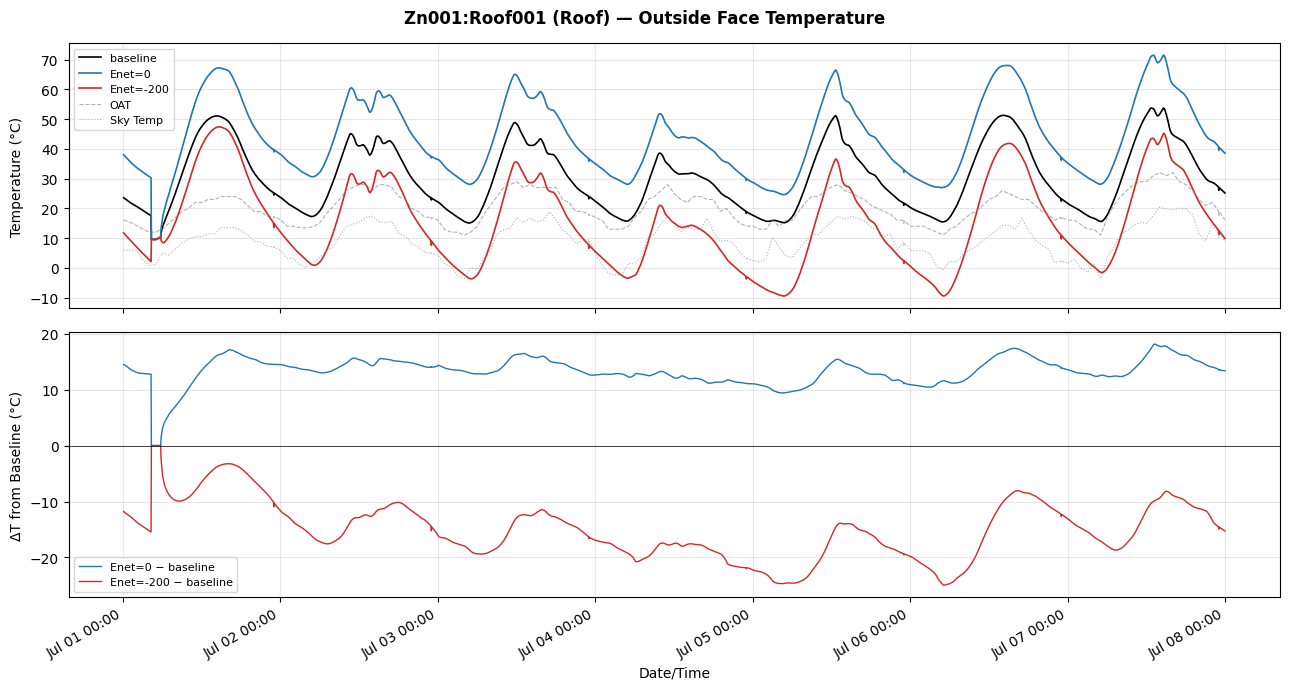

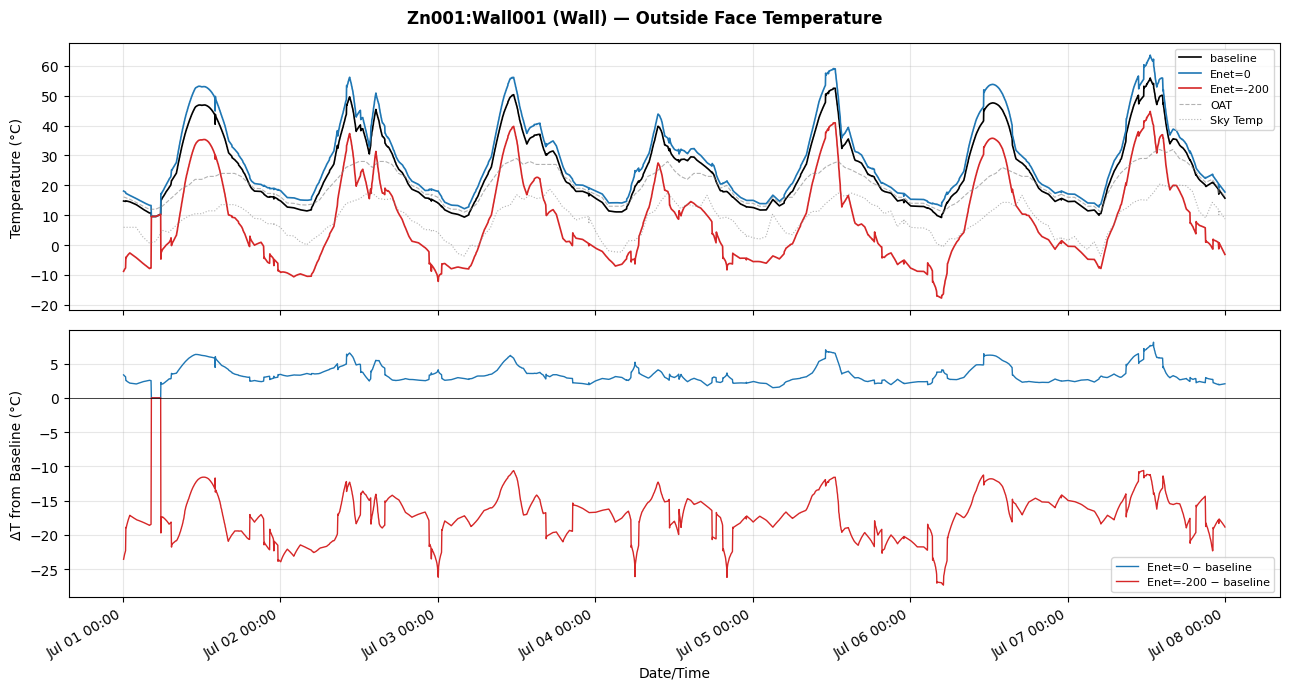

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

COLORS_RUN = {"baseline": "black"}
_palette = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
for i, enet in enumerate(ENET_VALUES):
    COLORS_RUN[f"Enet={enet}"] = _palette[i % len(_palette)]

def setup_time_ax(ax, ylabel):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

def pick_representative_surfaces(eligible_list):
    """Pick first roof and first wall from eligible surfaces."""
    roof = next((s["name"] for s in eligible_list if s["type"].lower() == "roof"), None)
    wall = next((s["name"] for s in eligible_list if s["type"].lower() == "wall"), None)
    result = []
    if roof: result.append((roof, "Roof"))
    if wall: result.append((wall, "Wall"))
    if not result:  # fallback: first surface
        result.append((eligible_list[0]["name"], eligible_list[0]["type"]))
    return result

def dedup_dt(df_run, col):
    """Mean-aggregate duplicate datetimes for a single surface/run slice."""
    return df_run.groupby("datetime")[col].mean()

rep_surfaces = pick_representative_surfaces(eligible)
runs = df["run"].unique()

if len(df) > 0:
    for surf_name, surf_type in rep_surfaces:
        sdf = df[df["surface"] == surf_name]
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
        fig.suptitle(f"{surf_name} ({surf_type}) \u2014 Outside Face Temperature", fontsize=12, fontweight="bold")

        # Top: time series
        for run_label in runs:
            rdf = sdf[sdf["run"] == run_label].sort_values("datetime")
            ts = dedup_dt(rdf, "surf_temp_C")
            ax1.plot(ts.index, ts.values,
                     color=COLORS_RUN.get(run_label, "gray"), linewidth=1.2, label=run_label)
        bdf = sdf[sdf["run"] == "baseline"].sort_values("datetime")
        b_oat = dedup_dt(bdf, "oat_C")
        b_sky = dedup_dt(bdf, "sky_temp_C")
        ax1.plot(b_oat.index, b_oat.values, "--", color="gray", linewidth=0.8, alpha=0.6, label="OAT")
        ax1.plot(b_sky.index, b_sky.values, ":", color="gray", linewidth=0.8, alpha=0.6, label="Sky Temp")
        setup_time_ax(ax1, "Temperature (\u00b0C)")
        ax1.legend(loc="best", fontsize=8)

        # Bottom: difference from baseline
        b_ts = dedup_dt(bdf, "surf_temp_C")
        for run_label in runs:
            if run_label == "baseline":
                continue
            rdf = sdf[sdf["run"] == run_label].sort_values("datetime")
            r_ts = dedup_dt(rdf, "surf_temp_C")
            common = b_ts.index.intersection(r_ts.index)
            diff = r_ts.loc[common] - b_ts.loc[common]
            ax2.plot(common, diff.values,
                     color=COLORS_RUN.get(run_label, "gray"), linewidth=1.0, label=f"{run_label} \u2212 baseline")
        ax2.axhline(0, color="black", linewidth=0.5)
        setup_time_ax(ax2, "\u0394T from Baseline (\u00b0C)")
        ax2.legend(loc="best", fontsize=8)
        ax2.set_xlabel("Date/Time")

        plt.tight_layout()
        plt.show()

---
## Plot 2: LW Radiation Flux

Net thermal radiation on roof and wall across all runs.

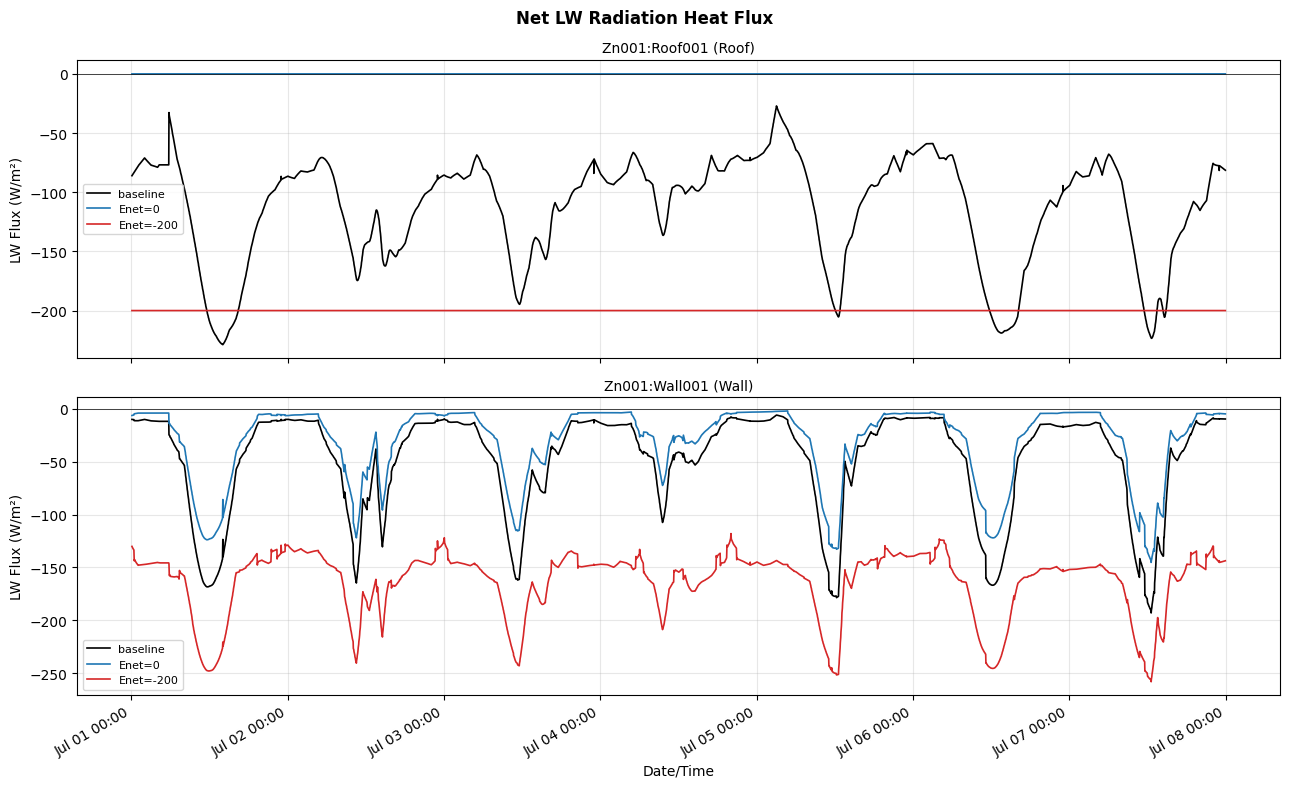

In [7]:
if len(df) > 0:
    n_surfs = len(rep_surfaces)
    fig, axes = plt.subplots(n_surfs, 1, figsize=(13, 4 * n_surfs), sharex=True)
    if n_surfs == 1: axes = [axes]
    fig.suptitle("Net LW Radiation Heat Flux", fontsize=12, fontweight="bold")

    for idx, (surf_name, surf_type) in enumerate(rep_surfaces):
        ax = axes[idx]
        sdf = df[df["surface"] == surf_name]
        for run_label in runs:
            rdf = sdf[sdf["run"] == run_label].sort_values("datetime")
            ax.plot(rdf["datetime"], rdf["lw_rad_Wm2"],
                    color=COLORS_RUN.get(run_label, "gray"), linewidth=1.2, label=run_label)
        ax.axhline(0, color="black", linewidth=0.5)
        setup_time_ax(ax, "LW Flux (W/m\u00b2)")
        ax.set_title(f"{surf_name} ({surf_type})", fontsize=10)
        ax.legend(loc="best", fontsize=8)

    axes[-1].set_xlabel("Date/Time")
    plt.tight_layout()
    plt.show()

---
## Plot 3: Outside Face Heat Balance Breakdown

LW radiation, convection, and conduction for baseline vs each override.
Shows how the heat balance components shift when sky LW is changed.

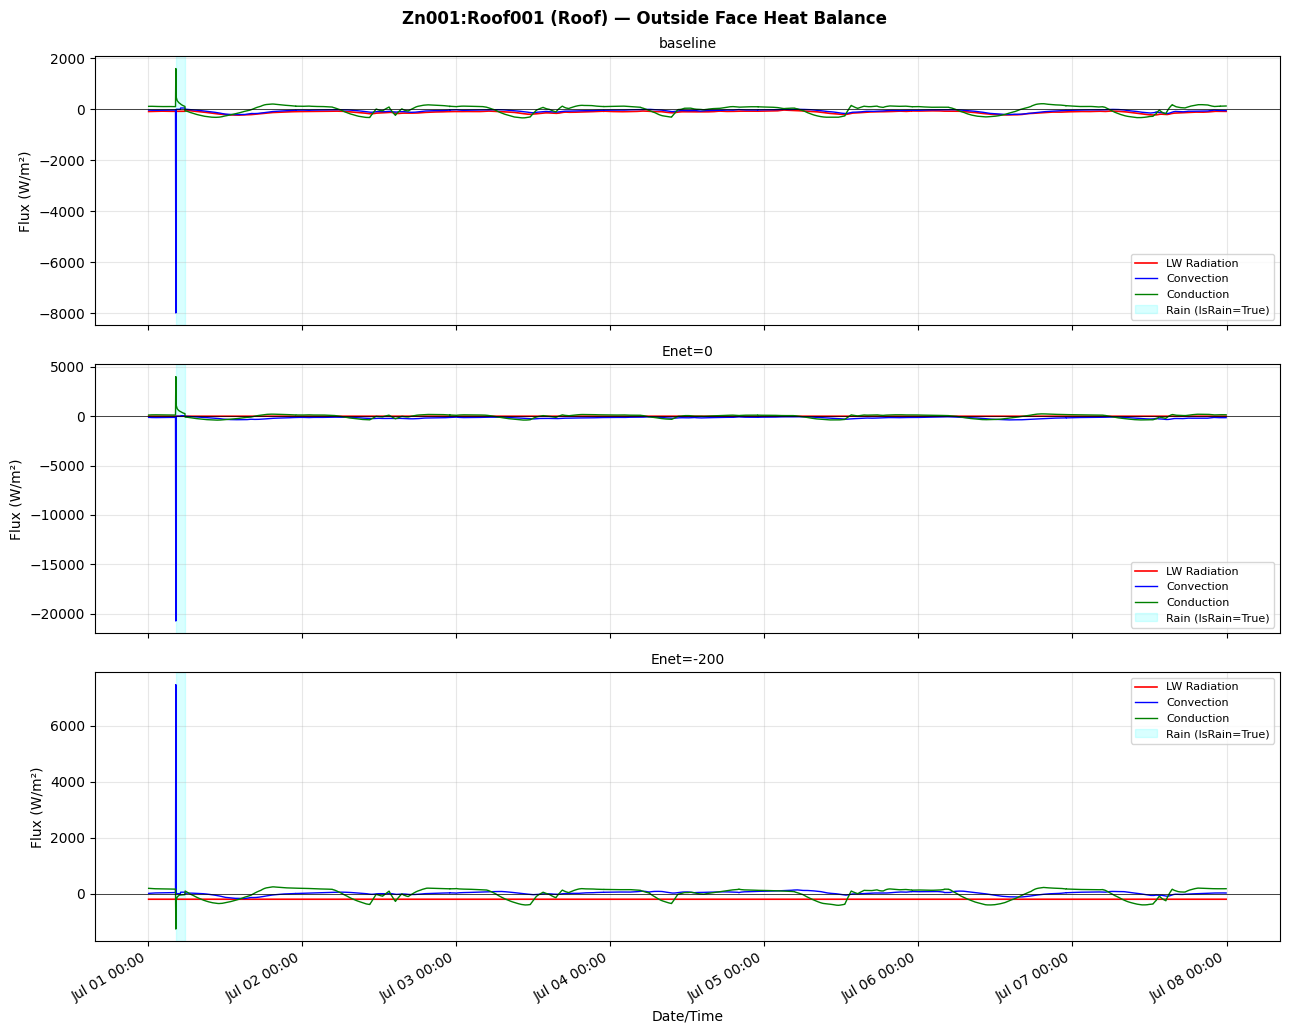

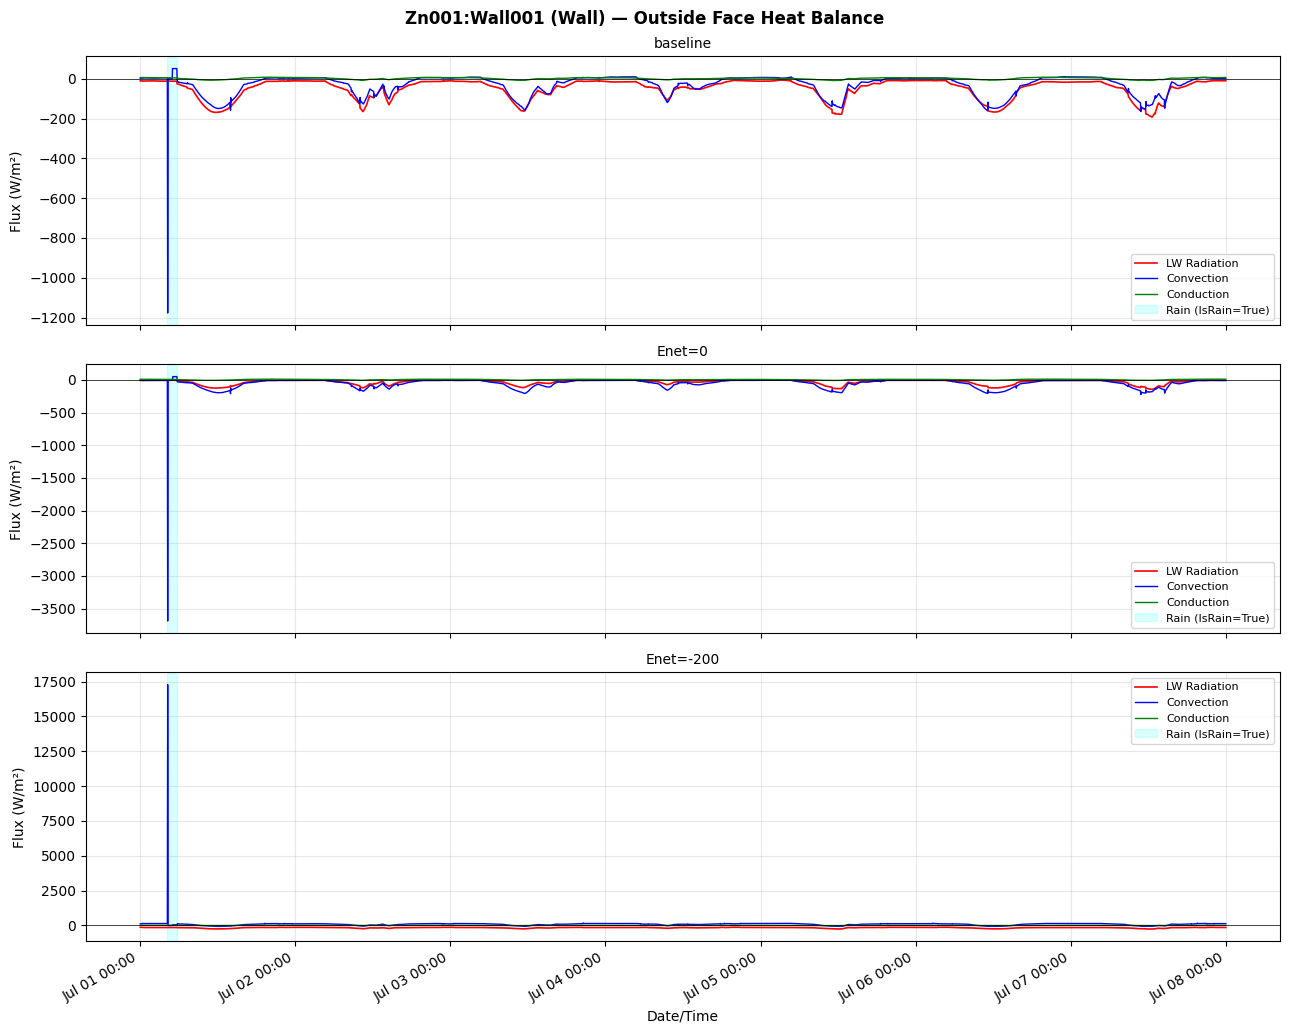

In [8]:
if len(df) > 0:
    for surf_name, surf_type in rep_surfaces:
        sdf = df[df["surface"] == surf_name]
        n_runs = len(runs)
        fig, axes = plt.subplots(n_runs, 1, figsize=(13, 3.5 * n_runs), sharex=True)
        if n_runs == 1: axes = [axes]
        fig.suptitle(f"{surf_name} ({surf_type}) \u2014 Outside Face Heat Balance", fontsize=12, fontweight="bold")

        for idx, run_label in enumerate(runs):
            ax = axes[idx]
            rdf = sdf[sdf["run"] == run_label].sort_values("datetime")
            ax.plot(rdf["datetime"], rdf["lw_rad_Wm2"], "r-", linewidth=1.2, label="LW Radiation")
            ax.plot(rdf["datetime"], rdf["conv_Wm2"], "b-", linewidth=1.0, label="Convection")
            ax.plot(rdf["datetime"], rdf["cond_Wm2"], "g-", linewidth=1.0, label="Conduction")
            # Shade rain periods: EnergyPlus sets SurfHConvExt=1000 during rain, forcing
            # outside face → wet-bulb temperature and producing large transient conv spikes.
            if "is_raining" in rdf.columns and rdf["is_raining"].any():
                import matplotlib.transforms as mtransforms
                trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
                ax.fill_between(rdf["datetime"], 0, 1, transform=trans,
                                where=rdf["is_raining"].values,
                                alpha=0.15, color="cyan", label="Rain (IsRain=True)")
            ax.axhline(0, color="black", linewidth=0.5)
            setup_time_ax(ax, "Flux (W/m\u00b2)")
            ax.set_title(run_label, fontsize=10)
            ax.legend(loc="best", fontsize=8)

        axes[-1].set_xlabel("Date/Time")
        plt.tight_layout()
        plt.show()

### Reading the heat balance plot shading

**Cyan shading — rain event (`IsRain=True`)**
EnergyPlus switches to *rain mode* whenever the weather file marks a timestep as raining.
In rain mode the exterior convection coefficient is set to **1000 W/m²·K** (from the usual ~5–15 W/m²·K)
and the outside-face boundary temperature is driven toward the **wet-bulb temperature**
rather than the dry-bulb temperature.
For a CondFD surface this causes the outside node to snap toward the wet-bulb value in a single
timestep; the resulting convective flux `= −1000×(T_surf − T_wetbulb)` can be thousands of W/m²,
producing the large spikes visible in the Convection trace.
This is physically real — a brief, intense evaporative cooling pulse — not a numerical artefact.
The cyan shading marks every timestep where `IsRain=True` so you can distinguish rain-driven
transients from the ordinary dry-weather heat balance.

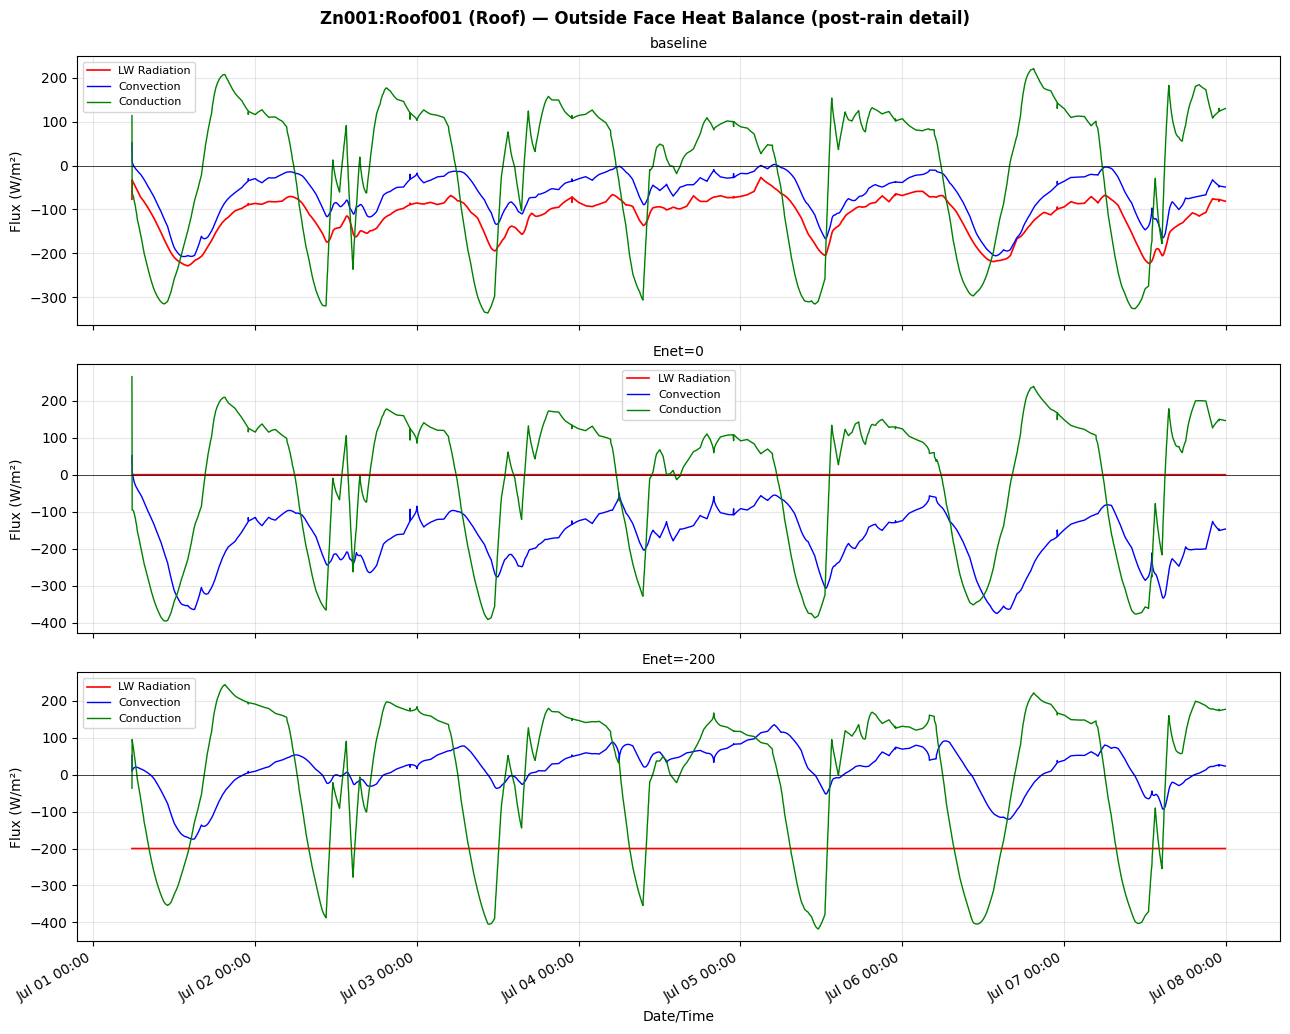

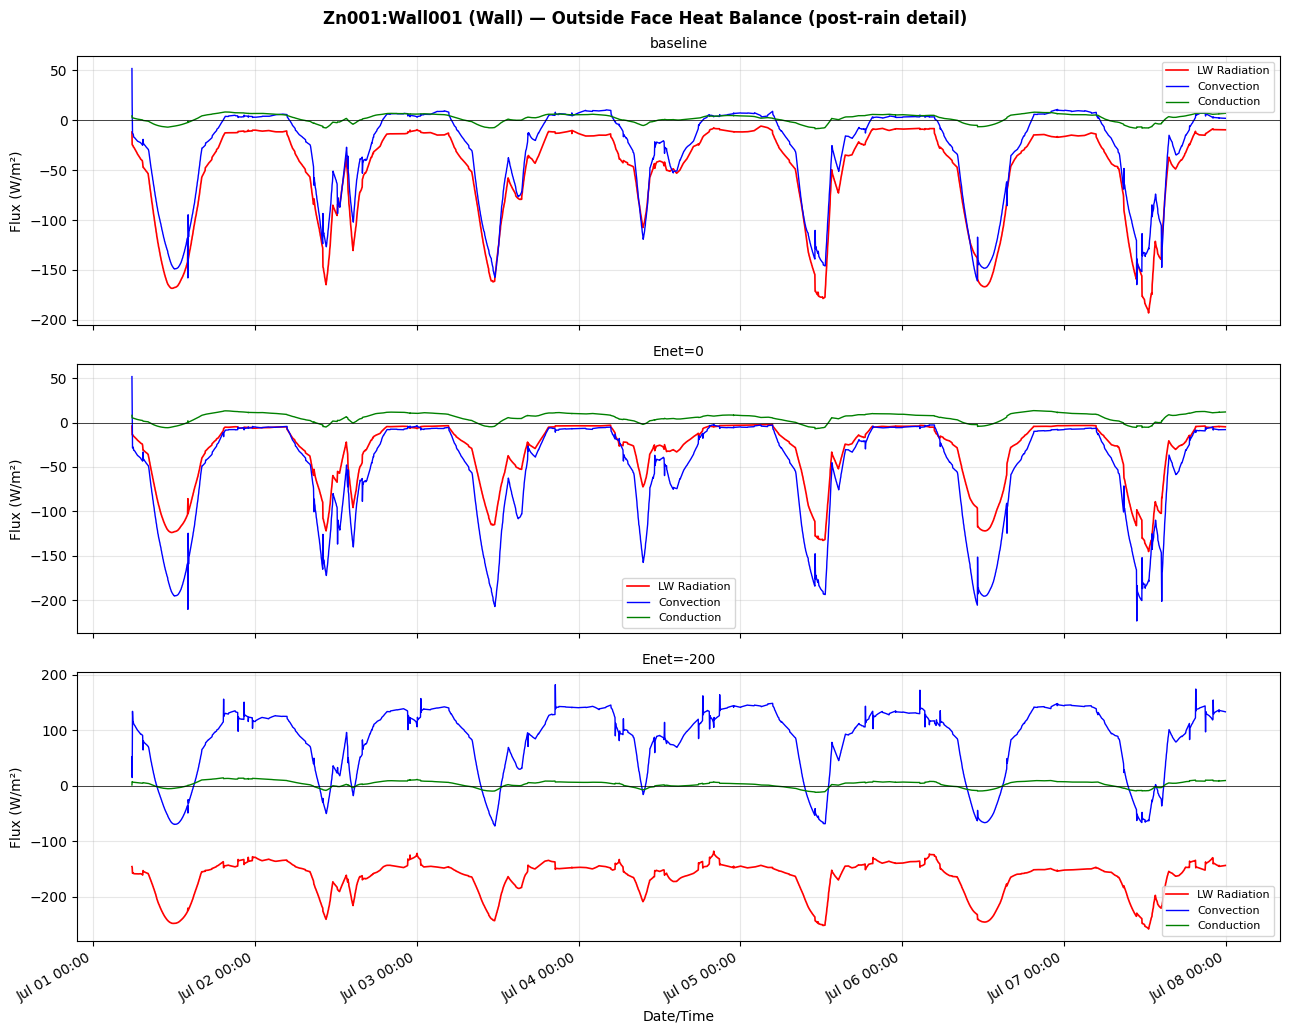

In [9]:
# Post-rain detail: same heat balance breakdown but x-axis starts just after the last
# rain timestep so the dry-weather detail is visible without the spike compressing the scale.
if len(df) > 0 and "is_raining" in df.columns and df["is_raining"].any():
    rain_end = df[df["is_raining"]]["datetime"].max()
    all_times = sorted(df["datetime"].unique())
    try:
        zoom_start = all_times[all_times.index(rain_end) + 1]
    except (ValueError, IndexError):
        zoom_start = rain_end

    for surf_name, surf_type in rep_surfaces:
        sdf = df[df["surface"] == surf_name]
        n_runs = len(runs)
        fig, axes = plt.subplots(n_runs, 1, figsize=(13, 3.5 * n_runs), sharex=True)
        if n_runs == 1: axes = [axes]
        fig.suptitle(
            f"{surf_name} ({surf_type}) — Outside Face Heat Balance (post-rain detail)",
            fontsize=12, fontweight="bold"
        )

        for idx, run_label in enumerate(runs):
            ax = axes[idx]
            rdf = sdf[(sdf["run"] == run_label)].sort_values("datetime")
            rdf = rdf[rdf["datetime"] >= zoom_start]
            ax.plot(rdf["datetime"], rdf["lw_rad_Wm2"], "r-", linewidth=1.2, label="LW Radiation")
            ax.plot(rdf["datetime"], rdf["conv_Wm2"],   "b-", linewidth=1.0, label="Convection")
            ax.plot(rdf["datetime"], rdf["cond_Wm2"],   "g-", linewidth=1.0, label="Conduction")
            ax.axhline(0, color="black", linewidth=0.5)
            setup_time_ax(ax, "Flux (W/m²)")
            ax.set_title(run_label, fontsize=10)
            ax.legend(loc="best", fontsize=8)

        axes[-1].set_xlabel("Date/Time")
        plt.tight_layout()
        plt.show()
else:
    print("No rain events in data — post-rain detail plot not needed.")


---
## Plot 4: Zone Air Temperature

Zone mean air temp for each zone that has an overridden surface.

In [10]:
if len(df) > 0:
    # Get zones from representative surfaces
    rep_zones = []
    for surf_name, surf_type in rep_surfaces:
        zone = next((s["zone"] for s in eligible if s["name"] == surf_name), None)
        if zone and zone not in [z[0] for z in rep_zones]:
            rep_zones.append((zone, surf_name))

    # Check if zone temp data is in our collected data (it's not â€” we need to add it)
    # Zone temp requires a separate variable handle. For now, note this limitation.
    print("Note: Zone air temperature requires adding 'Zone Mean Air Temperature' variable handle")
    print(f"Zones associated with representative surfaces: {[z[0] for z in rep_zones]}")
    print("This plot is available in the Phase 2 validation scripts (compare_runs.py).")

Note: Zone air temperature requires adding 'Zone Mean Air Temperature' variable handle
Zones associated with representative surfaces: ['ZONE ONE']
This plot is available in the Phase 2 validation scripts (compare_runs.py).


---
## Plot 5: EMS Actuator Value

The `CondFD EMS Sky Longwave Radiation Override Heat Flux` output variable,
confirming the actuator is applied at the correct value each timestep.

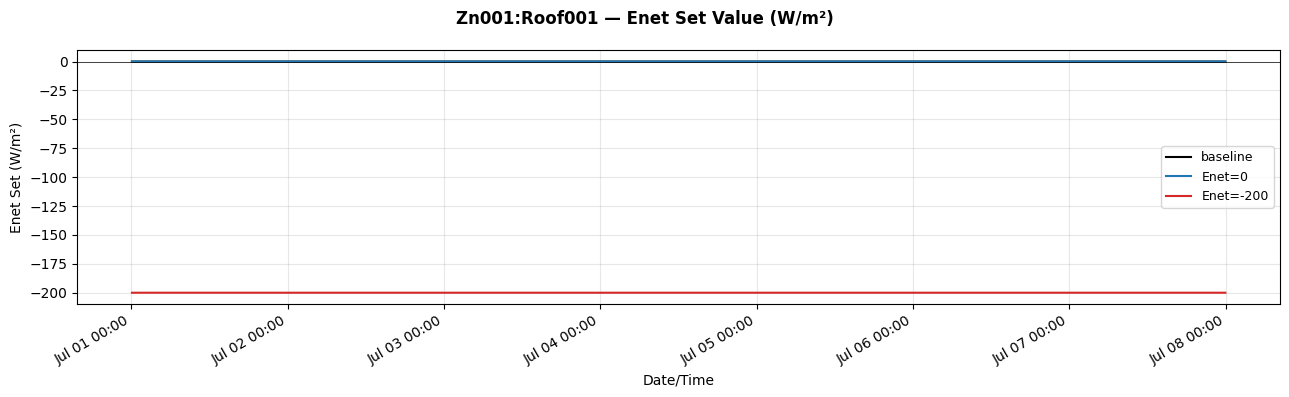

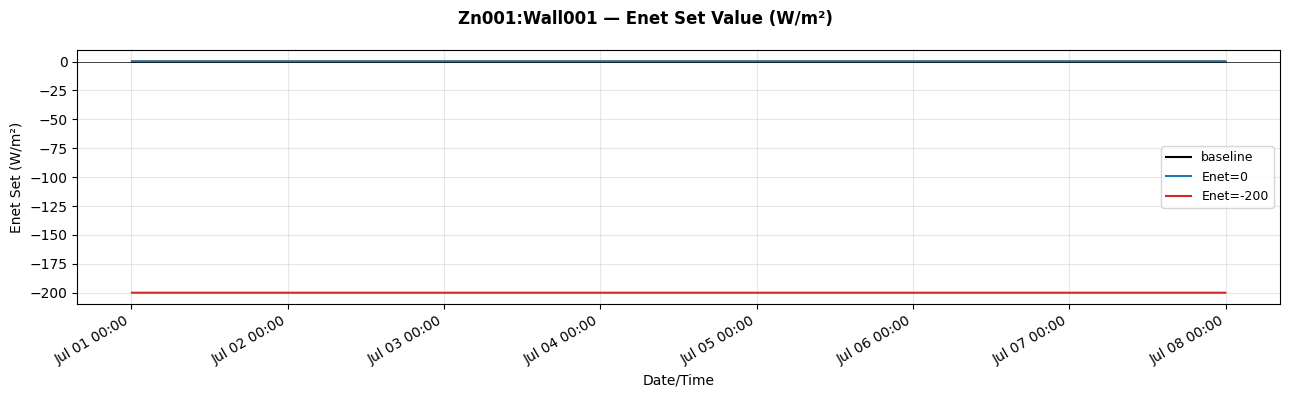

In [11]:
if len(df) > 0:
    for surf_name, surf_type in rep_surfaces:
        sdf = df[df["surface"] == surf_name]
        fig, ax = plt.subplots(figsize=(13, 4))
        fig.suptitle(f"{surf_name} \u2014 Enet Set Value (W/m\u00b2)", fontsize=12, fontweight="bold")

        for run_label in runs:
            rdf = sdf[sdf["run"] == run_label].sort_values("datetime")
            ts = dedup_dt(rdf, "enet_set_Wm2")
            ax.plot(ts.index, ts.values,
                    color=COLORS_RUN.get(run_label, "gray"), linewidth=1.5, label=run_label)

        ax.axhline(0, color="black", linewidth=0.5)
        setup_time_ax(ax, "Enet Set (W/m\u00b2)")
        ax.set_xlabel("Date/Time")
        ax.legend(loc="best", fontsize=9)
        plt.tight_layout()
        plt.show()

---
## Export results

In [12]:
if len(df) > 0:
    out_csv = Path(IDF_FILE).stem + "_enet_results.csv"
    df.to_csv(out_csv, index=False)
    print(f"Saved to {out_csv}")
    print(f"\nRun output directories:")
    for label, rdir in run_dirs.items():
        print(f"  {label}: {rdir}")

Saved to 1ZoneCondFD_Enet_Test_enet_results.csv

Run output directories:
  baseline: C:\Users\Brian\AppData\Local\Temp\enet_baseline_yr23qopd
  Enet=0: C:\Users\Brian\AppData\Local\Temp\enet_Enet=0_dlgnr5ob
  Enet=-200: C:\Users\Brian\AppData\Local\Temp\enet_Enet=-200_zm_lyqcp


---
## Advanced: Time-varying Enet from CSV

Supply a time-series instead of a constant (e.g. from COMSOL or pyrgeometer data).

CSV format: `month, day, hour, enet_Wm2` (hour is fractional, values are interpolated).

  Running csv_enet (168 rows)... OK (16795 pts). Dir: C:\Users\Brian\AppData\Local\Temp\enet_csv_jotz4i6w


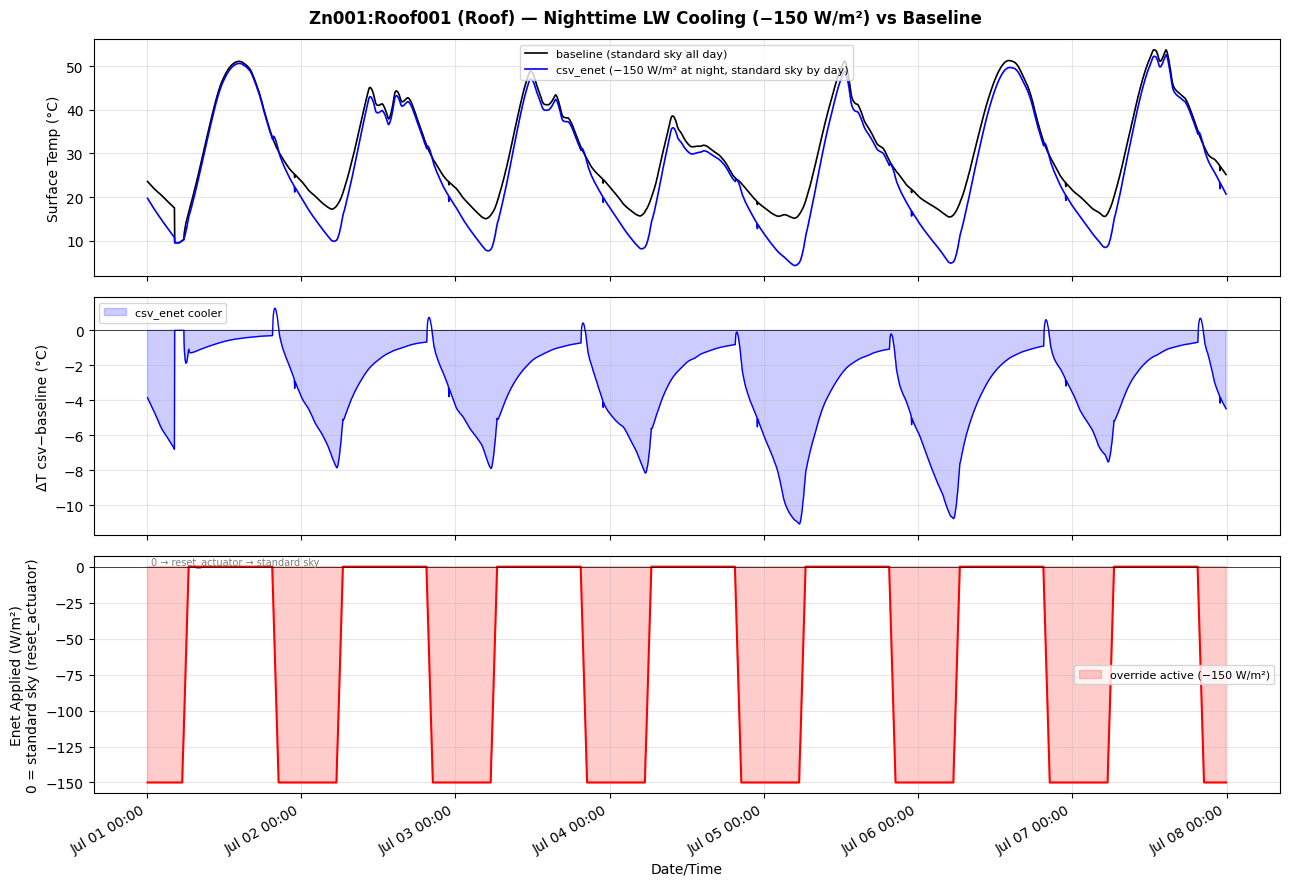

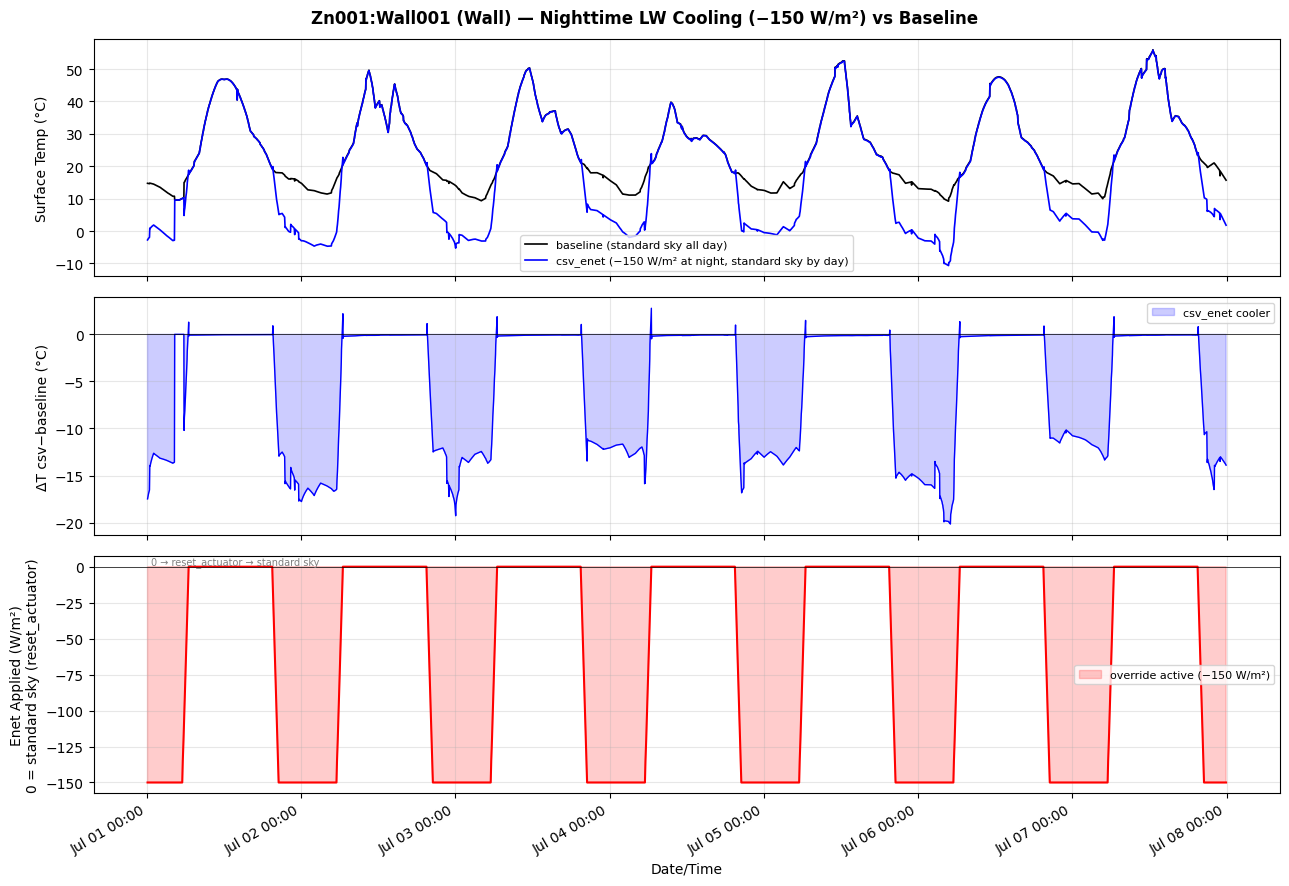

In [13]:
def run_with_csv_enet(idf_file, epw_file, target_surfaces, enet_csv_path, run_period):
    """Run EnergyPlus with a time-varying Enet schedule from a CSV file.

    CSV format: month, day, hour, enet_Wm2
        - hour is fractional (e.g. 6.5 = 06:30)
        - values are linearly interpolated between CSV rows at each EnergyPlus timestep

    How the actuator is controlled each timestep:

        enet_now != 0  â†’  set_actuator_value(enet_now)
            In C: writes value to *theActuator.RealValue and sets *theActuator.Actuated = true.
            The Actuated pointer points into surfFD.enetActuator.isActuated, so
            ExteriorBCEqns sees isActuated=true and uses actuatedValue instead of
            hsky*(Tsky-Tsurf).

        enet_now == 0  â†’  reset_actuator()
            In C: sets *theActuator.Actuated = false (that's the entire implementation).
            ExteriorBCEqns sees isActuated=false and runs the standard sky LW term.
            This is physically identical to the baseline run â€” NOT "zero sky radiation",
            which would be set_actuator_value(0) with isActuated=true.

    Important â€” np.interp and step transitions:
        np.interp linearly interpolates between CSV rows, so a schedule that jumps
        from -150 at hour 5.5 to 0 at hour 6.5 will produce intermediate values
        (e.g. -75 at hour 6.0).  Those intermediate timesteps get set_actuator_value,
        not reset_actuator, because enet_now != 0.

        For a hard on/off step with no ramp, duplicate rows at the transition:
            7, 1, 5.999, -150
            7, 1, 6.000,    0
        This makes np.interp snap from -150 to 0 with no interpolated values between,
        so reset_actuator fires immediately at the transition timestep.

    The first real timestep after warmup is skipped (same as run_single) because
    get_variable_value at that point reads the last warmup step's values.

    Returns a list of per-timestep data dicts.
    """
    import numpy as np

    enet_schedule = pd.read_csv(enet_csv_path)
    required_cols = {"month", "day", "hour", "enet_Wm2"}
    if not required_cols.issubset(enet_schedule.columns):
        print(f"ERROR: CSV must have columns {required_cols}")
        return []

    # Convert (month, day, hour) to a monotonic sequence-hour index for np.interp.
    # Assumes 744 hours/month (31-day months); fine for short runs within one month.
    enet_schedule["seq_hour"] = (
        (enet_schedule["month"] - 1) * 744
        + (enet_schedule["day"] - 1) * 24
        + enet_schedule["hour"]
    )
    seq_hours = enet_schedule["seq_hour"].values  # x-axis for interpolation
    enet_vals = enet_schedule["enet_Wm2"].values  # y-axis for interpolation

    _api = EnergyPlusAPI()
    _state = _api.state_manager.new_state()
    _run_dir = mkdtemp(prefix="enet_csv_")
    _data = []

    def _make_callback():
        ready = [False]       # True after one-time handle lookup completes
        act_handles = [{}]    # surf_name â†’ actuator handle int
        var_handles  = [{}]   # surf_name â†’ dict of output-variable handle ints
        global_vh   = [{}]    # site-level variable handles
        post_warmup = [True]  # True until the first real non-warmup timestep has been skipped

        def _cb(st):
            # --- One-time handle lookup (same as run_single) ---
            if not ready[0]:
                if not _api.exchange.api_data_fully_ready(st):
                    return
                for surf in target_surfaces:
                    h = _api.exchange.get_actuator_handle(
                        st, "CondFD Surface", "Sky Longwave Radiation Override", surf)
                    if h != -1:
                        act_handles[0][surf] = h
                        var_handles[0][surf] = {
                            "surf_temp": _api.exchange.get_variable_handle(
                                st, "Surface Outside Face Temperature", surf),
                            "lw_rad": _api.exchange.get_variable_handle(
                                st, "Surface Outside Face Net Thermal Radiation Heat Gain Rate per Area", surf),
                        }
                global_vh[0] = {
                    "oat":      _api.exchange.get_variable_handle(
                        st, "Site Outdoor Air Drybulb Temperature", "Environment"),
                    "sky_temp": _api.exchange.get_variable_handle(
                        st, "Site Sky Temperature", "Environment"),
                }
                ready[0] = True

            # --- Interpolate CSV to get Enet for this timestep ---
            month = _api.exchange.month(st)
            day   = _api.exchange.day_of_month(st)
            hour  = _api.exchange.hour(st) + _api.exchange.minutes(st) / 60.0
            current_seq = (month - 1) * 744 + (day - 1) * 24 + hour
            enet_now = float(np.interp(current_seq, seq_hours, enet_vals))

            # --- Apply or release actuator ---
            for surf, h in act_handles[0].items():
                if enet_now != 0.0:
                    # Override: sets *theActuator.RealValue = enet_now and
                    # *theActuator.Actuated = true â†’ ExteriorBCEqns uses enet_now.
                    _api.exchange.set_actuator_value(st, h, enet_now)
                else:
                    # Release: sets *theActuator.Actuated = false â†’
                    # ExteriorBCEqns falls through to standard hsky*(Tsky-Tsurf).
                    _api.exchange.reset_actuator(st, h)

            if _api.exchange.warmup_flag(st):
                post_warmup[0] = True
                return

            # Skip first real timestep after warmup (variable values are from last warmup step).
            if post_warmup[0]:
                post_warmup[0] = False
                return

            # --- Collect results ---
            h_int = int(hour)
            m_int = int((hour - h_int) * 60)
            try:
                dt = datetime(2024, int(month), int(day), min(h_int, 23), min(m_int, 59))
            except ValueError:
                dt = datetime(2024, 1, 1)

            for surf in act_handles[0]:
                vh = var_handles[0][surf]
                _data.append({
                    "datetime":     dt,
                    "month":        month,
                    "day":          day,
                    "hour":         hour,
                    "surface":      surf,
                    "oat_C":        _api.exchange.get_variable_value(st, global_vh[0]["oat"]),
                    "sky_temp_C":   _api.exchange.get_variable_value(st, global_vh[0]["sky_temp"]),
                    # Surface outside face temperature (Â°C)
                    "surf_temp_C":  _api.exchange.get_variable_value(st, vh["surf_temp"]),
                    # Net longwave radiation at outside face (W/mÂ²)
                    "lw_rad_Wm2":   _api.exchange.get_variable_value(st, vh["lw_rad"]),
                    # Enet value applied this timestep (0.0 means actuator was released â†’ standard sky)
                    "enet_set_Wm2": enet_now,
                    "is_raining":   _api.exchange.is_raining(st),
                    "run": "csv_enet",
                })

        return _cb

    _api.runtime.callback_begin_zone_timestep_after_init_heat_balance(_state, _make_callback())
    args = ["-d", _run_dir, "-w", epw_file, idf_file]
    if run_period == "design_day":
        args = ["-D"] + args
    print(f"  Running csv_enet ({len(enet_schedule)} rows)...", end=" ", flush=True)
    ret = _api.runtime.run_energyplus(_state, args)
    _api.state_manager.delete_state(_state)
    print(f"{'OK' if ret == 0 else 'FAILED'} ({len(_data)} pts). Dir: {_run_dir}")
    return _data


# ---------------------------------------------------------------
# enet_diurnal_july.csv â€” nighttime clear-sky LW cooling schedule
#
#   Night (20:00â€“06:00): enet = -150 W/mÂ²
#       Actuator ON: overrides sky LW with a strong fixed cooling flux.
#       Represents a clear night where the sky acts as a cold radiator.
#
#   Day (06:00â€“20:00): enet = 0  â†’ reset_actuator fires
#       Actuator RELEASED: EnergyPlus uses its standard hsky*(Tsky-Tsurf) term.
#       Behavior is identical to the baseline run during this window.
#
# Expected result:
#   - Daytime:  csv_enet â‰ˆ baseline (same sky physics)
#   - Nighttime: csv_enet < baseline (extra -150 W/mÂ² cooling)
#   - Î”T goes negative at sunset, recovers to ~0 by mid-morning
# ---------------------------------------------------------------
CSV_ENET_FILE = str(Path(IDF_FILE).parent.parent / "scripts" / "enet_diurnal_july.csv")

csv_data = run_with_csv_enet(effective_idf, EPW_FILE, target_surfaces, CSV_ENET_FILE, RUN_PERIOD)

if csv_data:
    csv_df = pd.DataFrame(csv_data)
    csv_df["datetime"] = pd.to_datetime(csv_df["datetime"])

    for surf_name, surf_type in rep_surfaces:
        sdf_base = df[(df["surface"] == surf_name) & (df["run"] == "baseline")]
        sdf_csv  = csv_df[csv_df["surface"] == surf_name]

        b_temp = dedup_dt(sdf_base, "surf_temp_C")
        c_temp = dedup_dt(sdf_csv,  "surf_temp_C")
        c_enet = dedup_dt(sdf_csv,  "enet_set_Wm2")

        fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
        fig.suptitle(
            f"{surf_name} ({surf_type}) \u2014 Nighttime LW Cooling (\u2212150 W/m\u00b2) vs Baseline",
            fontsize=12, fontweight="bold"
        )

        # Panel 1: surface temp â€” should diverge at night, converge during day
        axes[0].plot(b_temp.index, b_temp.values, "k-", lw=1.2, label="baseline (standard sky all day)")
        axes[0].plot(c_temp.index, c_temp.values, "b-", lw=1.2, label="csv_enet (\u2212150 W/m\u00b2 at night, standard sky by day)")
        setup_time_ax(axes[0], "Surface Temp (\u00b0C)")
        axes[0].legend(fontsize=8)

        # Panel 2: Î”T â€” negative when override is active, near zero when released
        common = b_temp.index.intersection(c_temp.index)
        diff = c_temp.loc[common] - b_temp.loc[common]
        axes[1].plot(common, diff.values, "b-", lw=1.0)
        axes[1].axhline(0, color="black", lw=0.5)
        axes[1].fill_between(common, diff.values, 0,
                              where=(diff.values < 0), alpha=0.2, color="blue",
                              label="csv_enet cooler")
        setup_time_ax(axes[1], "\u0394T csv\u2212baseline (\u00b0C)")
        axes[1].legend(fontsize=8)

        # Panel 3: the Enet schedule (0 = standard sky active, âˆ’150 = override active)
        axes[2].plot(c_enet.index, c_enet.values, "r-", lw=1.5)
        axes[2].fill_between(c_enet.index, c_enet.values, 0,
                              where=(c_enet.values < 0), alpha=0.2, color="red",
                              label="override active (\u2212150 W/m\u00b2)")
        axes[2].axhline(0, color="black", lw=0.5)
        axes[2].annotate("0 \u2192 reset_actuator \u2192 standard sky", xy=(c_enet.index[10], 2),
                         fontsize=7, color="gray")
        setup_time_ax(axes[2], "Enet Applied (W/m\u00b2)\n0 = standard sky (reset_actuator)")
        axes[2].set_xlabel("Date/Time")
        axes[2].legend(fontsize=8)

        plt.tight_layout()
        plt.show()

### Reading the CSV plot shaded areas

**Panel 2 â€” blue shading (Î”T csv âˆ’ baseline)**
Shaded wherever the csv_enet surface temperature is *colder* than baseline (diff < 0).
This is the direct thermal signature of the nighttime override: when the actuator is active
(âˆ’150 W/mÂ²) the outside face loses more heat to the sky than it would under the standard
TMY sky term, so the surface cools further.  The shading should appear every night and
disappear each morning when the actuator is released and both runs revert to the same sky physics.
If the shading persists during the day, the daytime reset is not working correctly.

**Panel 3 â€” red shading (Enet applied < 0)**
Shaded wherever `enet_set_Wm2 < 0`, i.e. the timesteps where `set_actuator_value(âˆ’150)` was
called instead of `reset_actuator`.  This is purely the schedule â€” it does not directly show
temperature, only *when* the override was active.  Comparing panel 3 to panel 2 lets you verify
that the temperature response (blue) is time-aligned with the forcing (red): the Î”T should
start going negative shortly after the red shading begins each evening, and recover after it ends
each morning.  Any lag between the two is real thermal mass â€” the wall takes time to respond.